# Aula prática – Keras para TinyML
## Classificação de atividades humanas (HAR) com o dataset WISDM

### Objetivo
Vamos seguir o mesmo fluxo típico de TinyML da aula de anomalia térmica, mas agora com **dados reais de acelerômetro** do dataset WISDM:

1. carregar os dados do acelerômetro;
2. criar janelas;
3. extrair features;
4. treinar **duas arquiteturas** (Densa × Conv1D) e compará-las;
5. avaliar os modelos;
6. **quantizar para int8** e validar a perda de acurácia (< 3%);
7. gerar os gráficos finais (matriz de confusão e curva ROC) do **modelo quantizado**.

### Pergunta central
Como aplicar o mesmo pipeline de TinyML a um problema real de reconhecimento de atividades a partir de um sensor de movimento?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, label_binarize
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    roc_curve,
    auc,
)

import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import layers

## 1. Contexto do problema

O dataset **WISDM** (Wireless Sensor Data Mining) contém leituras de acelerômetro de smartphones
de 36 usuários realizando 6 atividades:

- `Walking` (andar)
- `Jogging` (correr)
- `Upstairs` (subir escadas)
- `Downstairs` (descer escadas)
- `Sitting` (sentado)
- `Standing` (em pé)

Cada leitura tem 3 eixos de aceleração: **x, y, z**.

### Nossa estratégia
Em vez de classificar uma única leitura, vamos usar **janelas de leituras** para capturar o
padrão de movimento ao longo do tempo. Cada janela alimenta os modelos de duas formas:
features estatísticas por eixo (para a rede Densa) e o sinal bruto (para a Conv1D).

In [2]:
columns = ['user', 'activity', 'timestamp', 'x-accel', 'y-accel', 'z-accel']
raw_path = './WISDM_ar_v1.1_raw.txt'

with open(raw_path, 'r') as f:
    content = f.read()

records = []
for record in content.split(';'):
    fields = record.strip().split(',')
    if len(fields) == 6 and fields[0] != '':
        records.append(fields)

df = pd.DataFrame(records, columns=columns)

df['user'] = df['user'].astype(int)
df['timestamp'] = df['timestamp'].astype('int64')
df['x-accel'] = pd.to_numeric(df['x-accel'], errors='coerce')
df['y-accel'] = pd.to_numeric(df['y-accel'], errors='coerce')
df['z-accel'] = pd.to_numeric(df['z-accel'], errors='coerce')

df = df.dropna().reset_index(drop=True)

print(f'Total de registros: {len(df)}')
df.head()

Total de registros: 1086474


,user,activity,timestamp,x-accel,y-accel,z-accel
0,33,Jogging,49105962326000,-0.694638,12.680544,0.503953
1,33,Jogging,49106062271000,5.012288,11.264028,0.953424
2,33,Jogging,49106112167000,4.903325,10.882658,-0.081722
3,33,Jogging,49106222305000,-0.612916,18.496431,3.023717
4,33,Jogging,49106332290000,-1.184970,12.108489,7.205164


In [3]:
print("Distribuição das atividades:")
print(df["activity"].value_counts())

Distribuição das atividades:
activity
Walking       418394
Jogging       336450
Upstairs      122869
Downstairs    100427
Sitting        59939
Standing       48395
Name: count, dtype: int64


## 2. Visualizando o sinal

Vamos observar o comportamento dos 3 eixos do acelerômetro para algumas atividades.

### O que esperamos ver?
- atividades dinâmicas (`Walking`, `Jogging`) têm sinais com muita oscilação e padrões periódicos;
- atividades estáticas (`Sitting`, `Standing`) têm sinais quase constantes.

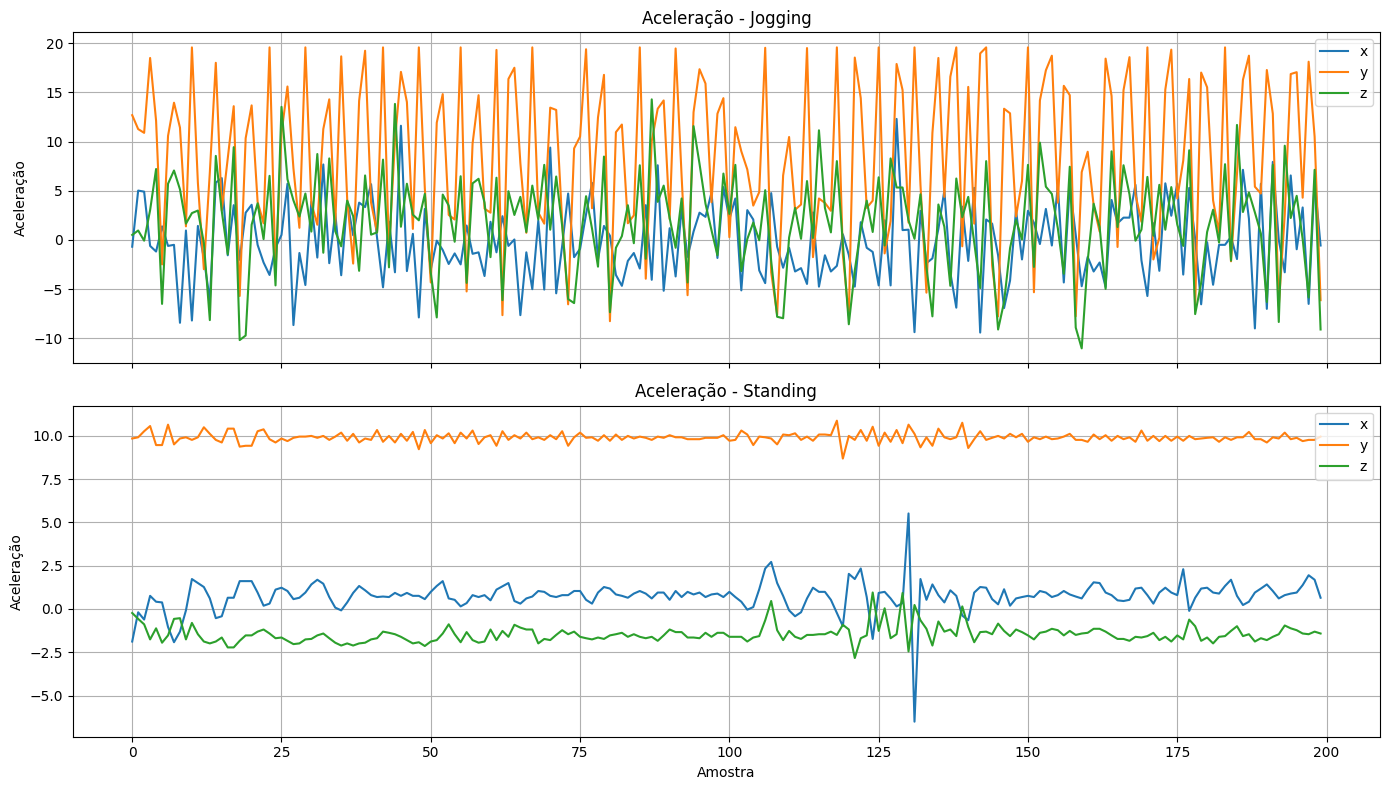

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(14, 8), sharex=True)

for ax, atividade in zip(axes, ["Jogging", "Standing"]):
    trecho = df[df["activity"] == atividade].head(200)
    ax.plot(trecho["x-accel"].values, label="x")
    ax.plot(trecho["y-accel"].values, label="y")
    ax.plot(trecho["z-accel"].values, label="z")
    ax.set_title(f"Aceleração - {atividade}")
    ax.set_ylabel("Aceleração")
    ax.grid(True)
    ax.legend(loc="upper right")

axes[-1].set_xlabel("Amostra")
plt.tight_layout()
plt.show()

## 3. Criando janelas e features

### Por que usar janelas?
Uma leitura isolada de aceleração não diz muito.
Uma janela de leituras captura o **padrão de movimento** ao longo do tempo.

### Features da janela (para a rede Densa)
Para cada janela de 80 leituras (~4 segundos a 20 Hz), vamos calcular, **para cada eixo (x, y, z)**:
- média
- desvio padrão
- máximo

Isso resulta em `3 eixos x 3 features = 9 features` por janela.

### Janela bruta (para a Conv1D)
Guardamos também a janela bruta no formato `(80, 3)`, que a Conv1D usará diretamente.

### Rótulo da janela
O rótulo da janela é a atividade que mais aparece dentro dela (voto da maioria).

In [5]:
WINDOW_SIZE = 80   # ~4 s de dados a 20 Hz
STEP = 40          # 50% de sobreposicao entre janelas
AXES = ["x-accel", "y-accel", "z-accel"]


def create_sliding_windows(frame, window_size=WINDOW_SIZE, step=STEP):
    X_windows = []
    y_windows = []

    valores = frame[AXES].values
    atividades = frame["activity"].values

    for i in range(0, len(frame) - window_size + 1, step):
        janela = valores[i:i + window_size]
        rotulos = atividades[i:i + window_size]

        # rotulo = atividade mais frequente na janela (voto da maioria)
        rotulo = pd.Series(rotulos).mode()[0]

        X_windows.append(janela)
        y_windows.append(rotulo)

    return np.array(X_windows), np.array(y_windows)


def extract_features(windows):
    features = []
    for janela in windows:
        feats = []
        for eixo in range(janela.shape[1]):
            sinal = janela[:, eixo]
            feats.append(np.mean(sinal))
            feats.append(np.std(sinal))
            feats.append(np.max(sinal))
        features.append(feats)
    return np.array(features)

In [6]:
# Ordena por usuario e tempo para que as janelas respeitem a sequencia temporal
df_sorted = df.sort_values(["user", "timestamp"]).reset_index(drop=True)

X_windows, y_labels = create_sliding_windows(df_sorted)
X_features = extract_features(X_windows)

print("Formato das janelas:", X_windows.shape)
print("Formato das features:", X_features.shape)
print("Formato dos rotulos:", y_labels.shape)

Formato das janelas: (27160, 80, 3)
Formato das features: (27160, 9)
Formato dos rotulos: (27160,)


## 4. Entendendo a entrada da rede Densa

Cada janela é representada por **9 números**:

`[media_x, desvio_x, maximo_x, media_y, desvio_y, maximo_y, media_z, desvio_z, maximo_z]`

Portanto a rede Densa recebe vetores no formato `(9,)`.

In [7]:
feature_names = [
    "media_x", "desvio_x", "maximo_x",
    "media_y", "desvio_y", "maximo_y",
    "media_z", "desvio_z", "maximo_z",
]

features_df = pd.DataFrame(X_features, columns=feature_names)
features_df["activity"] = y_labels
features_df.head()

,media_x,desvio_x,maximo_x,media_y,desvio_y,maximo_y,media_z,desvio_z,maximo_z,activity
0,3.643500,5.449704,19.57,9.784250,3.749458,19.23,-0.390500,3.412389,10.88,Walking
1,3.671750,5.797496,19.57,9.904750,4.198527,19.50,-0.607125,3.542371,12.11,Walking
2,3.824500,5.939786,19.57,10.015750,4.494045,19.50,-0.739750,2.970321,12.11,Walking
3,3.864500,5.815026,19.57,10.122375,4.401588,19.11,-0.693375,3.238339,10.61,Walking
4,3.976625,5.753998,19.57,10.021500,4.489350,19.50,-0.442250,3.656289,11.50,Walking


## 5. Codificando os rótulos

Temos **6 classes**. Vamos converter os nomes das atividades em números inteiros (0 a 5).

In [8]:
classes = sorted(np.unique(y_labels))
class_to_idx = {c: i for i, c in enumerate(classes)}
idx_to_class = {i: c for c, i in class_to_idx.items()}

y_encoded = np.array([class_to_idx[a] for a in y_labels])

num_classes = len(classes)
print("Classes:", classes)
print("Mapeamento:", class_to_idx)

Classes: [np.str_('Downstairs'), np.str_('Jogging'), np.str_('Sitting'), np.str_('Standing'), np.str_('Upstairs'), np.str_('Walking')]
Mapeamento: {np.str_('Downstairs'): 0, np.str_('Jogging'): 1, np.str_('Sitting'): 2, np.str_('Standing'): 3, np.str_('Upstairs'): 4, np.str_('Walking'): 5}


## 6. Separando treino e teste

Fazemos a divisão **uma única vez, por índices**, para que as duas representações
(features `(9,)` e janela bruta `(80, 3)`) fiquem alinhadas e usem exatamente as
mesmas amostras de treino/teste — assim a comparação entre as arquiteturas é justa.
Usamos `stratify` para manter a proporção das classes.

In [9]:
indices = np.arange(len(X_features))

idx_train, idx_test, y_train, y_test = train_test_split(
    indices,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

X_train = X_features[idx_train]
X_test = X_features[idx_test]

X_train_win = X_windows[idx_train]
X_test_win = X_windows[idx_test]

print("Treino:", X_train.shape, "| janelas:", X_train_win.shape)
print("Teste: ", X_test.shape, "| janelas:", X_test_win.shape)

Treino: (21728, 9) | janelas: (21728, 80, 3)
Teste:  (5432, 9) | janelas: (5432, 80, 3)


## 7. Normalizando as features (rede Densa)

As features de aceleração têm escalas diferentes (média, desvio e máximo variam bastante).
Padronizamos (`média 0`, `desvio 1`) com o `StandardScaler`.

> Importante: o scaler é ajustado **apenas no treino** e depois aplicado ao teste.
> Os parâmetros do scaler também precisam ser usados na inferência no dispositivo.

In [10]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
X_test_scaled = scaler.transform(X_test).astype(np.float32)

print("Media (treino):", np.round(scaler.mean_, 3))
print("Escala (treino):", np.round(scaler.scale_, 3))

Media (treino): [ 0.676  4.438 10.319  7.223  4.924 16.475  0.397  3.721 10.883]
Escala (treino): [4.472 2.759 6.722 3.769 2.66  5.026 2.251 1.94  4.586]


## 8. Modelo A — Rede Densa (9 features)

Rede neural pequena, adequada para TinyML, sobre as 9 features estatísticas.

### Estrutura
- entrada com 9 valores;
- camada oculta com 32 neurônios (`relu`);
- camada oculta com 16 neurônios (`relu`);
- saída com 6 neurônios (`softmax`).

### Por que `softmax` na saída?
Porque o problema é **multiclasse**: a saída é uma distribuição de probabilidade
sobre as 6 atividades, e escolhemos a de maior probabilidade.

In [11]:
model = keras.Sequential([
    layers.Input(shape=(9,)),
    layers.Dense(32, activation="relu"),
    layers.Dense(16, activation="relu"),
    layers.Dense(num_classes, activation="softmax")
])

## 9. Compilando o modelo Denso

- `optimizer="adam"`: método de ajuste dos pesos;
- `loss="sparse_categorical_crossentropy"`: perda adequada para classificação multiclasse com rótulos inteiros;
- `metrics=["accuracy"]`: métrica para acompanhar o desempenho.

In [12]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           102 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 950 (3.71 KB)

 Trainable params: 950 (3.71 KB)

 Non-trainable params: 0 (0.00 B)

## 10. Treinando o modelo Denso

In [13]:
history = model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=40,
    batch_size=32,
    verbose=1
)

Epoch 1/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 5s 5ms/step - accuracy: 0.7269 - loss: 0.8308 - val_accuracy: 0.8157 - val_loss: 0.5675
Epoch 2/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8122 - loss: 0.5374 - val_accuracy: 0.8290 - val_loss: 0.4974
Epoch 3/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.8295 - loss: 0.4792 - val_accuracy: 0.8399 - val_loss: 0.4644
Epoch 4/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8444 - loss: 0.4359 - val_accuracy: 0.8608 - val_loss: 0.4300
Epoch 5/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8555 - loss: 0.4067 - val_accuracy: 0.8695 - val_loss: 0.3982
Epoch 6/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8631 - loss: 0.3871 - val_accuracy: 0.8691 - val_loss: 0.3953
Epoch 7/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8672 - loss: 0.3713 - val_accuracy: 0.8746 - val_loss: 0.3723
Epoch 8/40
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8701 - loss: 0.3613 - val_accuracy: 0.

## 11. Curvas de treino (Denso)

Observamos a perda (`loss`) e a acurácia (`accuracy`) para entender se o modelo
está aprendendo e se há sobreajuste.

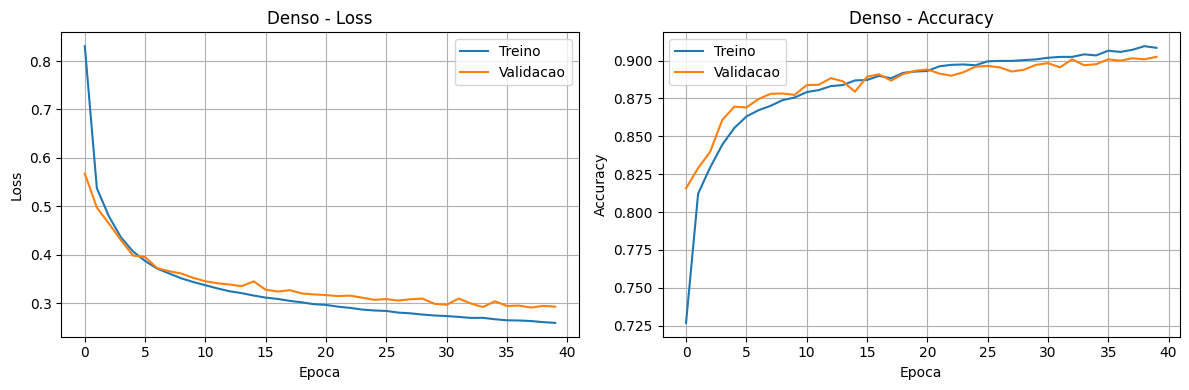

In [14]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Treino")
plt.plot(history.history["val_loss"], label="Validacao")
plt.title("Denso - Loss")
plt.xlabel("Epoca"); plt.ylabel("Loss"); plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Treino")
plt.plot(history.history["val_accuracy"], label="Validacao")
plt.title("Denso - Accuracy")
plt.xlabel("Epoca"); plt.ylabel("Accuracy"); plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

## 12. Avaliando o modelo Denso

Acurácia, relatório por classe e matriz de confusão no conjunto de teste.

170/170 ━━━━━━━━━━━━━━━━━━━━ 0s 858us/step
Acuracia (Denso): 0.9098

              precision    recall  f1-score   support

  Downstairs       0.68      0.77      0.72       502
     Jogging       0.97      0.99      0.98      1683
     Sitting       0.97      0.97      0.97       300
    Standing       0.97      0.96      0.97       242
    Upstairs       0.81      0.58      0.68       614
     Walking       0.93      0.96      0.95      2091

    accuracy                           0.91      5432
   macro avg       0.89      0.87      0.88      5432
weighted avg       0.91      0.91      0.91      5432



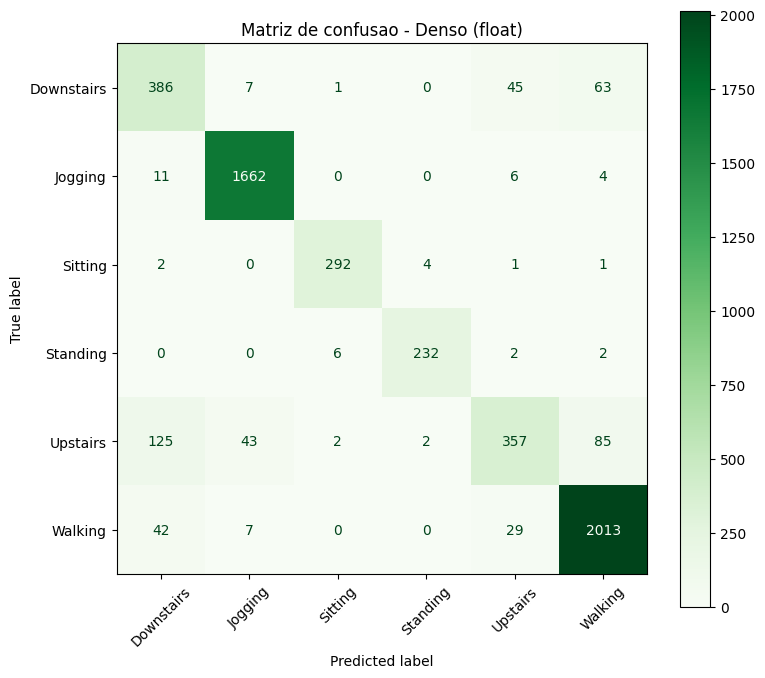

In [15]:
y_pred_prob = model.predict(X_test_scaled)
y_pred = np.argmax(y_pred_prob, axis=1)

dense_acc = accuracy_score(y_test, y_pred)
print(f"Acuracia (Denso): {dense_acc:.4f}\n")
print(classification_report(y_test, y_pred, target_names=classes))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(cmap="Greens", ax=ax, xticks_rotation=45)
plt.title("Matriz de confusao - Denso (float)")
plt.tight_layout()
plt.show()

## 13. Modelo B — Conv1D sobre a janela bruta

O modelo Denso usa **9 features estatísticas** já resumidas. Agora treinamos uma
**rede convolucional 1D (Conv1D)** que recebe diretamente a **janela bruta** de
`(80, 3)` — 80 leituras × 3 eixos — e aprende sozinha os padrões temporais, sem
precisarmos extrair features à mão.

Assim teremos **duas arquiteturas** para comparar (requisito da atividade):
- **Modelo A (Denso):** entrada `(9,)` — features estatísticas;
- **Modelo B (Conv1D):** entrada `(80, 3)` — sinal bruto.

### Normalização das janelas brutas

Padronizamos por eixo (x, y, z) usando **apenas as estatísticas do treino**.
Esses mesmos valores (`win_mean`, `win_std`) serão usados na inferência no dispositivo.

In [16]:
win_mean = X_train_win.reshape(-1, 3).mean(axis=0)
win_std = X_train_win.reshape(-1, 3).std(axis=0)

X_train_win_n = ((X_train_win - win_mean) / win_std).astype(np.float32)
X_test_win_n = ((X_test_win - win_mean) / win_std).astype(np.float32)

print("Janelas de treino:", X_train_win_n.shape)
print("Janelas de teste: ", X_test_win_n.shape)
print("Media por eixo:", np.round(win_mean, 3))
print("Desvio por eixo:", np.round(win_std, 3))

Janelas de treino: (21728, 80, 3)
Janelas de teste:  (5432, 80, 3)
Media por eixo: [0.676 7.223 0.397]
Desvio por eixo: [6.878 6.747 4.762]


### Estrutura da Conv1D

- `Conv1D(32)` + `MaxPooling1D` → extrai padrões locais no tempo;
- `Conv1D(64)` + `GlobalAveragePooling1D` → resume o sinal;
- `Dense(32)` → combinação das features aprendidas;
- `Dense(6, softmax)` → probabilidade das 6 atividades.

Continua sendo uma rede **pequena**, adequada para TinyML.

In [17]:
conv_model = keras.Sequential([
    layers.Input(shape=(WINDOW_SIZE, 3)),
    layers.Conv1D(32, kernel_size=3, activation="relu", padding="same"),
    layers.MaxPooling1D(pool_size=2),
    layers.Conv1D(64, kernel_size=3, activation="relu", padding="same"),
    layers.GlobalAveragePooling1D(),
    layers.Dense(32, activation="relu"),
    layers.Dense(num_classes, activation="softmax"),
])

conv_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 80, 32)         │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 40, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 40, 64)         │         6,208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 64)             │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           198 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,806 (34.40 KB)

 Trainable params: 8,806 (34.40 KB)

 Non-trainable params: 0 (0.00 B)

### Compilando e treinando a Conv1D

Mesmos hiperparâmetros do modelo Denso (`adam`, `sparse_categorical_crossentropy`),
para a comparação ser justa.

In [18]:
conv_model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

history_conv = conv_model.fit(
    X_train_win_n, y_train,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)

Epoch 1/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.7365 - loss: 0.7443 - val_accuracy: 0.8410 - val_loss: 0.4794
Epoch 2/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.8477 - loss: 0.4252 - val_accuracy: 0.8583 - val_loss: 0.3744
Epoch 3/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8706 - loss: 0.3547 - val_accuracy: 0.8757 - val_loss: 0.3344
Epoch 4/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.8918 - loss: 0.3118 - val_accuracy: 0.9027 - val_loss: 0.2937
Epoch 5/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - accuracy: 0.9042 - loss: 0.2785 - val_accuracy: 0.8976 - val_loss: 0.3218
Epoch 6/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.9136 - loss: 0.2533 - val_accuracy: 0.9024 - val_loss: 0.2989
Epoch 7/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9181 - loss: 0.2408 - val_accuracy: 0.9243 - val_loss: 0.2303
Epoch 8/30
544/544 ━━━━━━━━━━━━━━━━━━━━ 4s 7ms/step - accuracy: 0.9266 - loss: 0.2204 - val_accuracy: 0.

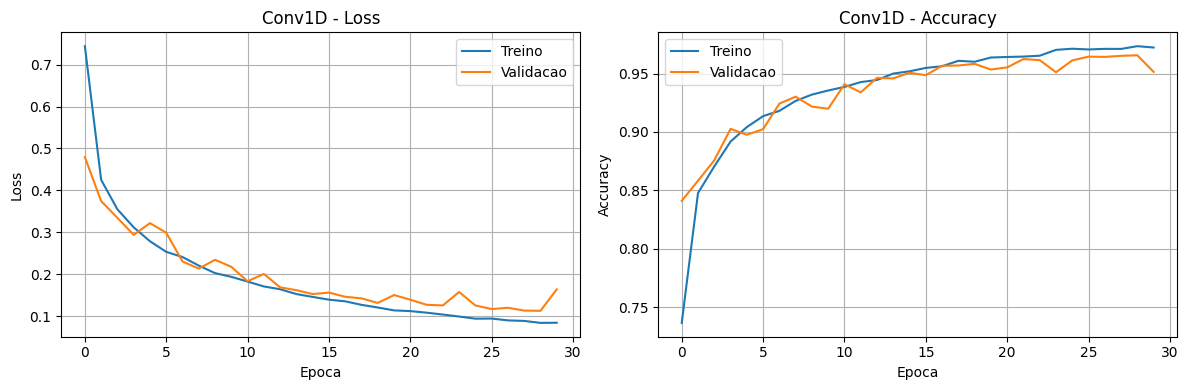

In [19]:
plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(history_conv.history["loss"], label="Treino")
plt.plot(history_conv.history["val_loss"], label="Validacao")
plt.title("Conv1D - Loss")
plt.xlabel("Epoca"); plt.ylabel("Loss"); plt.grid(True); plt.legend()

plt.subplot(1, 2, 2)
plt.plot(history_conv.history["accuracy"], label="Treino")
plt.plot(history_conv.history["val_accuracy"], label="Validacao")
plt.title("Conv1D - Accuracy")
plt.xlabel("Epoca"); plt.ylabel("Accuracy"); plt.grid(True); plt.legend()

plt.tight_layout()
plt.show()

### Avaliando a Conv1D no conjunto de teste

170/170 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step
Acuracia Conv1D: 0.9547

              precision    recall  f1-score   support

  Downstairs       0.99      0.70      0.82       502
     Jogging       0.98      0.99      0.99      1683
     Sitting       0.99      0.98      0.98       300
    Standing       0.98      0.98      0.98       242
    Upstairs       0.90      0.89      0.89       614
     Walking       0.94      1.00      0.97      2091

    accuracy                           0.95      5432
   macro avg       0.96      0.92      0.94      5432
weighted avg       0.96      0.95      0.95      5432



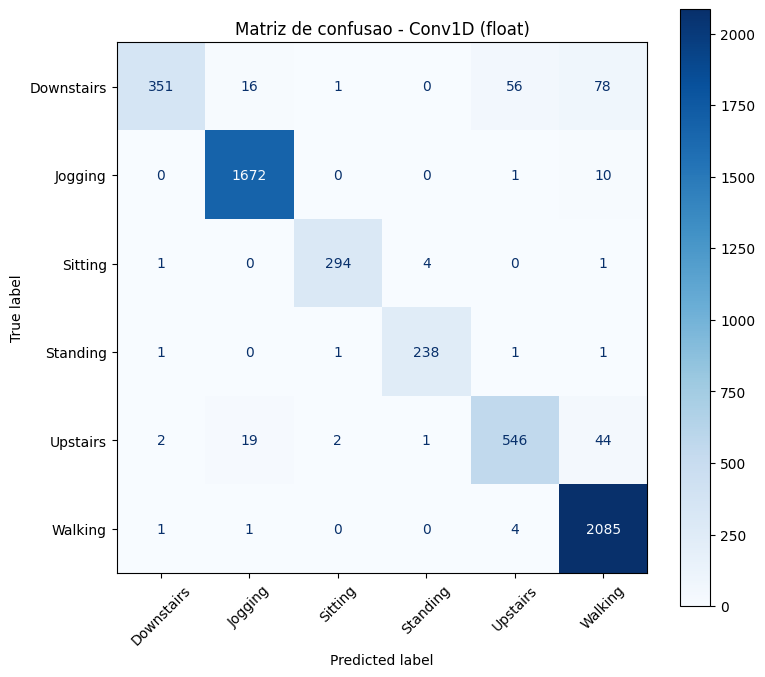

In [20]:
conv_pred_prob = conv_model.predict(X_test_win_n)
conv_pred = np.argmax(conv_pred_prob, axis=1)

conv_acc = accuracy_score(y_test, conv_pred)
print(f"Acuracia Conv1D: {conv_acc:.4f}\n")
print(classification_report(y_test, conv_pred, target_names=classes))

cm_conv = confusion_matrix(y_test, conv_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_conv, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(cmap="Blues", ax=ax, xticks_rotation=45)
plt.title("Matriz de confusao - Conv1D (float)")
plt.tight_layout()
plt.show()

## 14. Comparação das duas arquiteturas

Comparamos as redes pelo que importa em TinyML: **acurácia** no teste e
**tamanho** (número de parâmetros).

In [21]:
comparacao = pd.DataFrame({
    "Modelo": ["Denso (9 features)", "Conv1D (janela bruta)"],
    "Acuracia (teste)": [round(dense_acc, 4), round(conv_acc, 4)],
    "Parametros": [model.count_params(), conv_model.count_params()],
})

print(comparacao.to_string(index=False))

melhor = "Conv1D" if conv_acc >= dense_acc else "Denso"
print(f"\nMelhor acuracia: {melhor}")

               Modelo  Acuracia (teste)  Parametros
   Denso (9 features)            0.9098         950
Conv1D (janela bruta)            0.9547        8806

Melhor acuracia: Conv1D


## 15. Quantização int8 (full integer) do modelo Conv1D

Para rodar em um microcontrolador (ESP32), convertemos a rede para **TensorFlow Lite
com quantização inteira completa (int8)**: pesos **e** ativações viram inteiros de
8 bits, reduzindo memória e custo de inferência.

Escolhemos a **Conv1D** como modelo de implantação, pois recebe a janela bruta
(o `.h` será gerado a partir dela, em etapa separada).

> A quantização int8 completa exige um **`representative_dataset`**: algumas amostras
> reais de entrada para o conversor calibrar as faixas (scale/zero-point) de cada tensor.

In [22]:
def representative_dataset():
    # algumas centenas de janelas reais de treino para calibracao
    for i in range(min(300, len(X_train_win_n))):
        yield [X_train_win_n[i:i + 1]]

converter = tf.lite.TFLiteConverter.from_keras_model(conv_model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset
converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
converter.inference_input_type = tf.int8
converter.inference_output_type = tf.int8

tflite_int8 = converter.convert()

with open("wisdm_conv1d_int8.tflite", "wb") as f:
    f.write(tflite_int8)

print("Modelo int8 salvo em wisdm_conv1d_int8.tflite")
print(f"Tamanho: {len(tflite_int8) / 1024:.1f} KB")

INFO:tensorflow:Assets written to: C:\Users\kauef\AppData\Local\Temp\tmprpz6aa67\assets


INFO:tensorflow:Assets written to: C:\Users\kauef\AppData\Local\Temp\tmprpz6aa67\assets


Saved artifact at 'C:\Users\kauef\AppData\Local\Temp\tmprpz6aa67'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 80, 3), dtype=tf.float32, name='keras_tensor_4')
Output Type:
  TensorSpec(shape=(None, 6), dtype=tf.float32, name=None)
Captures:
  2789598204304: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789598214864: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789598215056: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789598212944: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789598206032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789598213328: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789598215248: TensorSpec(shape=(), dtype=tf.resource, name=None)
  2789598212752: TensorSpec(shape=(), dtype=tf.resource, name=None)


C:\Users\kauef\AppData\Roaming\Python\Python313\site-packages\tensorflow\lite\python\convert.py:846: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


Modelo int8 salvo em wisdm_conv1d_int8.tflite
Tamanho: 18.1 KB


## 16. Validação da perda de acurácia (< 3%)

Rodamos o modelo **quantizado int8** em todo o conjunto de teste e comparamos a
acurácia com a do modelo float. O requisito é que a perda seja **menor que 3%**.

Como a entrada/saída agora são `int8`, precisamos:
1. **quantizar** a entrada: `q = round(x / scale + zero_point)`;
2. **desquantizar** a saída: `y = (q - zero_point) * scale`.

In [23]:
interpreter = tf.lite.Interpreter(model_content=tflite_int8)
interpreter.allocate_tensors()

in_d = interpreter.get_input_details()[0]
out_d = interpreter.get_output_details()[0]
in_scale, in_zp = in_d["quantization"]
out_scale, out_zp = out_d["quantization"]

print("Entrada:", in_d["dtype"], "scale=", in_scale, "zero_point=", in_zp)
print("Saida:  ", out_d["dtype"], "scale=", out_scale, "zero_point=", out_zp)


def int8_predict_proba(x_float):
    """x_float: (n, 80, 3) ja normalizado -> retorna probabilidades (n, 6)."""
    probs = []
    for i in range(len(x_float)):
        xq = np.round(x_float[i] / in_scale + in_zp).astype(np.int8)
        interpreter.set_tensor(in_d["index"], xq[np.newaxis, ...])
        interpreter.invoke()
        oq = interpreter.get_tensor(out_d["index"])[0].astype(np.float32)
        probs.append((oq - out_zp) * out_scale)
    return np.array(probs)


q_pred_prob = int8_predict_proba(X_test_win_n)
q_pred = np.argmax(q_pred_prob, axis=1)

q_acc = accuracy_score(y_test, q_pred)
perda = conv_acc - q_acc

print(f"\nAcuracia Conv1D float: {conv_acc:.4f}")
print(f"Acuracia Conv1D int8:  {q_acc:.4f}")
print(f"Perda de acuracia:     {perda * 100:.2f} pontos percentuais")
print("OK (< 3%)" if perda < 0.03 else "ATENCAO: perda >= 3%")

Entrada: <class 'numpy.int8'> scale= 0.03195039927959442 zero_point= 4
Saida:   <class 'numpy.int8'> scale= 0.00390625 zero_point= -128


C:\Users\kauef\AppData\Roaming\Python\Python313\site-packages\tensorflow\lite\python\interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)



Acuracia Conv1D float: 0.9547
Acuracia Conv1D int8:  0.9571
Perda de acuracia:     -0.24 pontos percentuais
OK (< 3%)


## 17. Matriz de confusão e curva ROC do modelo quantizado

Gráficos finais (requisito da atividade) calculados sobre as previsões do
**modelo int8**, não do float.

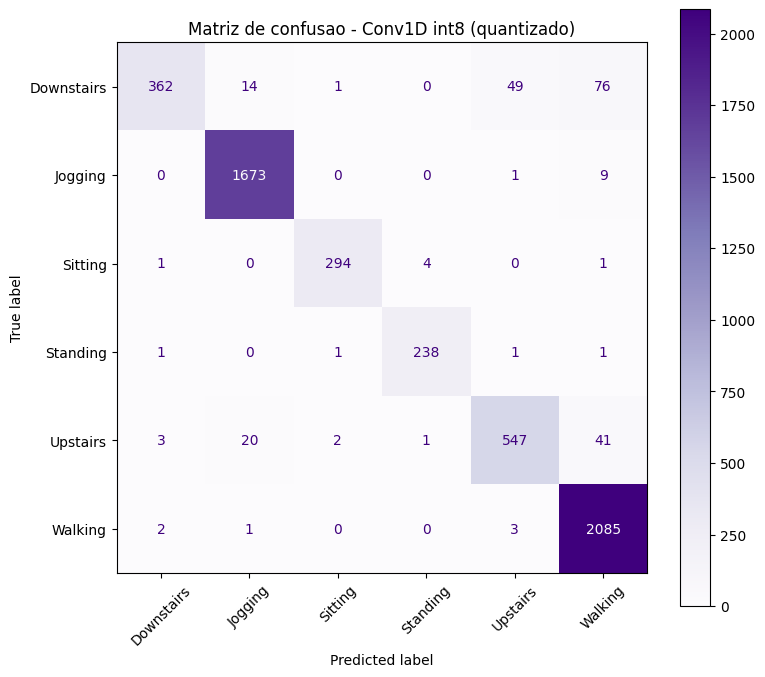

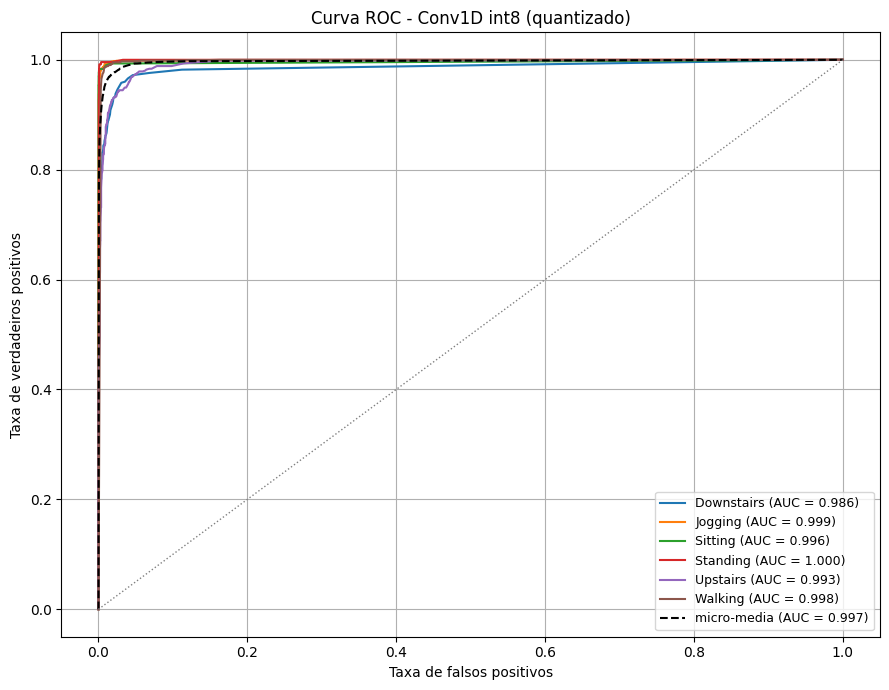

In [24]:
# --- Matriz de confusao do modelo quantizado ---
cm_q = confusion_matrix(y_test, q_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm_q, display_labels=classes)
fig, ax = plt.subplots(figsize=(8, 7))
disp.plot(cmap="Purples", ax=ax, xticks_rotation=45)
plt.title("Matriz de confusao - Conv1D int8 (quantizado)")
plt.tight_layout()
plt.show()

# --- Curva ROC (uma-contra-todas) do modelo quantizado ---
y_test_bin = label_binarize(y_test, classes=list(range(num_classes)))

plt.figure(figsize=(9, 7))
for i in range(num_classes):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], q_pred_prob[:, i])
    plt.plot(fpr, tpr, label=f"{classes[i]} (AUC = {auc(fpr, tpr):.3f})")

# media micro (agrega todas as classes)
fpr_micro, tpr_micro, _ = roc_curve(y_test_bin.ravel(), q_pred_prob.ravel())
plt.plot(fpr_micro, tpr_micro, "k--",
         label=f"micro-media (AUC = {auc(fpr_micro, tpr_micro):.3f})")

plt.plot([0, 1], [0, 1], color="gray", lw=1, linestyle=":")
plt.xlabel("Taxa de falsos positivos")
plt.ylabel("Taxa de verdadeiros positivos")
plt.title("Curva ROC - Conv1D int8 (quantizado)")
plt.legend(loc="lower right", fontsize=9)
plt.grid(True)
plt.tight_layout()
plt.show()

## 18. O que entregamos

Pipeline completo de TinyML para reconhecimento de atividades (WISDM):

- carregamento e limpeza dos dados de acelerômetro;
- janelas deslizantes sobre os 3 eixos + extração de features;
- normalização;
- **duas arquiteturas treinadas e comparadas**: Densa (9 features) × Conv1D (janela bruta);
- **quantização inteira completa (int8)** do modelo Conv1D, com perda de acurácia validada **< 3%**;
- **gráficos finais do modelo quantizado**: matriz de confusão e curva ROC.